<a href="https://colab.research.google.com/github/Ozk18532/INTELIGENCIA-COMPUTACIONAL-Oscar-Mercado/blob/main/ML.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# ==========================================
# 1️⃣ LIBRERÍAS
# ==========================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

import joblib


In [2]:
# ==========================================
# 2️⃣ CARGAR DATASET (PIMA DESDE URL)
# ==========================================
url = "https://raw.githubusercontent.com/plotly/datasets/master/diabetes.csv"
df = pd.read_csv(url)

print("Dimensiones:", df.shape)
display(df.head())


Dimensiones: (768, 9)


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1



Tipos de datos:
Pregnancies                   int64
Glucose                       int64
BloodPressure                 int64
SkinThickness                 int64
Insulin                       int64
BMI                         float64
DiabetesPedigreeFunction    float64
Age                           int64
Outcome                       int64
dtype: object

Estadísticas descriptivas:


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


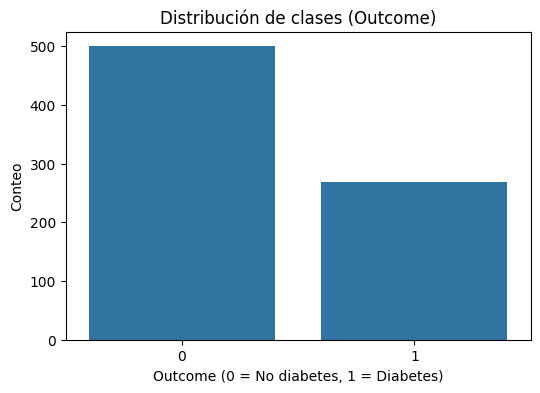

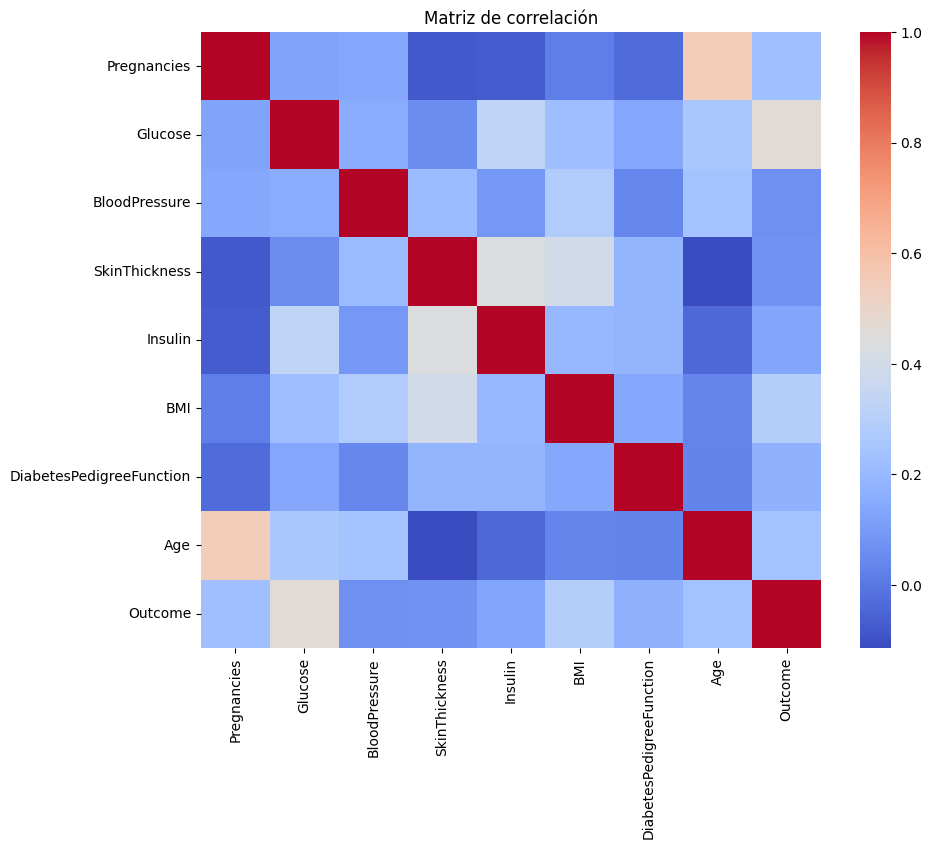

In [3]:
# ==========================================
# 3️⃣ EDA
# ==========================================
print("\nTipos de datos:")
print(df.dtypes)

print("\nEstadísticas descriptivas:")
display(df.describe())

plt.figure(figsize=(6,4))
sns.countplot(x="Outcome", data=df)
plt.title("Distribución de clases (Outcome)")
plt.xlabel("Outcome (0 = No diabetes, 1 = Diabetes)")
plt.ylabel("Conteo")
plt.show()

plt.figure(figsize=(10,8))
sns.heatmap(df.corr(), cmap="coolwarm")
plt.title("Matriz de correlación")
plt.show()


In [4]:
# ==========================================
# 4️⃣ PREPROCESAMIENTO + SPLIT
# ==========================================
X = df.drop("Outcome", axis=1).copy()
y = df["Outcome"].copy()

cols_con_ceros_invalidos = ["Glucose", "BloodPressure", "SkinThickness", "Insulin", "BMI"]
for c in cols_con_ceros_invalidos:
    if c in X.columns:
        X[c] = X[c].replace(0, np.nan)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Train:", X_train.shape, "Test:", X_test.shape)


Train: (614, 8) Test: (154, 8)


In [5]:
# ==========================================
# 5️⃣ PIPELINE + ENTRENAMIENTO
# ==========================================
pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(max_iter=2000))
])

pipe.fit(X_train, y_train)
print("Modelo entrenado ✅")


Modelo entrenado ✅


              precision    recall  f1-score   support

           0     0.7523    0.8200    0.7847       100
           1     0.6000    0.5000    0.5455        54

    accuracy                         0.7078       154
   macro avg     0.6761    0.6600    0.6651       154
weighted avg     0.6989    0.7078    0.7008       154



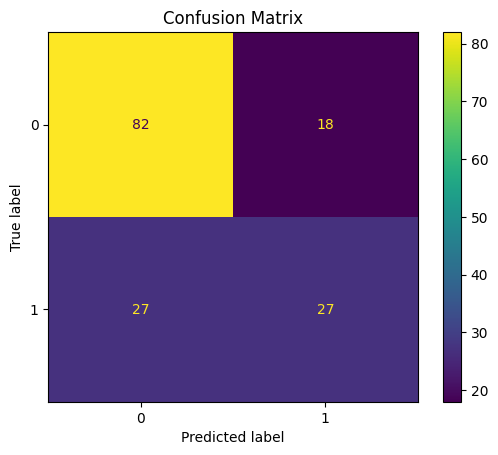

In [6]:
# ==========================================
# 6️⃣ MÉTRICAS + MATRIZ DE CONFUSIÓN
# ==========================================
y_pred = pipe.predict(X_test)

print(classification_report(y_test, y_pred, digits=4))

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.title("Confusion Matrix")
plt.show()


In [7]:
# ==========================================
# 7️⃣ UMBRALES DE RIESGO (percentiles)
# ==========================================
probs_train = pipe.predict_proba(X_train)[:, 1]  # probabilidad de clase 1

q33 = float(np.percentile(probs_train, 33))
q66 = float(np.percentile(probs_train, 66))

print("Q33:", q33)
print("Q66:", q66)

def riesgo_por_prob(p, q33, q66):
    if p < q33:
        return "Bajo"
    if p < q66:
        return "Medio"
    return "Alto"


Q33: 0.15011505956597823
Q66: 0.40888937446248397


In [8]:
# ==========================================
# 8️⃣ EXPORTAR MODELO + PRUEBA
# ==========================================
joblib.dump(pipe, "pima_diabetes_model.joblib")
print("Modelo guardado: pima_diabetes_model.joblib ✅")

model_loaded = joblib.load("pima_diabetes_model.joblib")
sample = X_test.iloc[0:1]
p = float(model_loaded.predict_proba(sample)[:, 1][0])
print("Probabilidad (sample):", round(p*100, 2), "%")


Modelo guardado: pima_diabetes_model.joblib ✅
Probabilidad (sample): 60.97 %


In [9]:
# ==========================================
# 9️⃣ ONNX: EXPORTAR + PROBAR
# ==========================================
!pip -q install skl2onnx onnx onnxruntime

from skl2onnx import convert_sklearn
from skl2onnx.common.data_types import FloatTensorType
import onnxruntime as ort

n_features = X_train.shape[1]
initial_type = [("float_input", FloatTensorType([None, n_features]))]

onnx_model = convert_sklearn(pipe, initial_types=initial_type)

with open("pima_diabetes_model.onnx", "wb") as f:
    f.write(onnx_model.SerializeToString())

print("ONNX guardado: pima_diabetes_model.onnx ✅")

sess = ort.InferenceSession("pima_diabetes_model.onnx", providers=["CPUExecutionProvider"])
input_name = sess.get_inputs()[0].name

x0 = X_test.iloc[0:1].to_numpy().astype(np.float32)
pred_onnx = sess.run(None, {input_name: x0})[0]

print("Salida ONNX (raw):", pred_onnx)


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 317.2/317.2 kB 5.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.5/17.5 MB 33.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.1/17.1 MB 36.8 MB/s eta 0:00:00
ONNX guardado: pima_diabetes_model.onnx ✅
Salida ONNX (raw): [1]


In [10]:
# ==========================================
# 🔟 GUI (GRADIO)
# ==========================================
!pip -q install gradio

import gradio as gr
import numpy as np
import joblib

model = joblib.load("pima_diabetes_model.joblib")

Q33 = q33
Q66 = q66

def riesgo(p):
    return riesgo_por_prob(p, Q33, Q66)

def predict(Pregnancies, Glucose, BloodPressure, SkinThickness, Insulin, BMI, DiabetesPedigreeFunction, Age):
    x = np.array([[Pregnancies, Glucose, BloodPressure, SkinThickness, Insulin, BMI, DiabetesPedigreeFunction, Age]], dtype=float)
    p = float(model.predict_proba(x)[0, 1])

    etiqueta = "Diabetes probable" if p >= 0.5 else "Diabetes no probable"
    nivel = riesgo(p)

    return f"{etiqueta} | Probabilidad: {p*100:.2f}% | Riesgo: {nivel}"

demo = gr.Interface(
    fn=predict,
    inputs=[
        gr.Slider(0, 17, value=1, step=1,
                  label="Número de embarazos",
                  info="Cantidad total de embarazos de la paciente."),

        gr.Slider(0, 200, value=120, step=1,
                  label="Nivel de glucosa (mg/dL)",
                  info="Valores mayores a 140 pueden indicar riesgo."),

        gr.Slider(0, 122, value=70, step=1,
                  label="Presión arterial (mmHg)",
                  info="Valores normales rondan 70–90 mmHg."),

        gr.Slider(0, 100, value=20, step=1,
                  label="Grosor de piel (mm)",
                  info="Relacionado con grasa corporal subcutánea."),

        gr.Slider(0, 900, value=80, step=1,
                  label="Nivel de insulina",
                  info="Puede variar ampliamente según el paciente."),

        gr.Slider(0, 70, value=28, step=0.1,
                  label="Índice de masa corporal (BMI)",
                  info="Normal: 18.5–24.9 | Sobrepeso: 25–29.9 | Obesidad: 30+"),

        gr.Slider(0, 2.5, value=0.5, step=0.01,
                  label="Historial familiar (Diabetes Pedigree Function)",
                  info="Mayor valor indica mayor predisposición genética."),

        gr.Slider(10, 90, value=33, step=1,
                  label="Edad (años)",
                  info="Edad del paciente en años.")
    ],
    outputs=gr.Textbox(label="Resultado del modelo"),
    title="Predicción de Diabetes (Pima Indians)",
    description="Modelo de clasificación basado en datos clínicos reales."
)


demo.launch(share=True)


Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://e00099217bf86acff8.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


In [11]:
# ==========================================
# 1️⃣1️⃣ DESCARGAR ARCHIVOS
# ==========================================
from google.colab import files
files.download("pima_diabetes_model.joblib")
files.download("pima_diabetes_model.onnx")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>